# LeetCode #98: Validate Binary Search Tree

https://leetcode.com/problems/validate-binary-search-tree/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Inorder traversal check | O(n) | O(n) | BST inorder = strictly sorted; check for violations |
| **DFS with Min/Max Bounds ★** | **O(n)** | **O(n)** | Pass (lo, hi) exclusive range down; any violation fails |

---

## Understanding the Methods

### Inorder Check
Inorder traversal of a BST produces strictly sorted output. Collect and check for violations. Works but requires O(n) extra space for the result.

### Optimal: DFS with Bounds ★
Each node must satisfy `lo < node.val < hi` where lo and hi are inherited from ancestors.

Call `Validate(root, -∞, +∞)`:
- Null node: valid.
- node.val ≤ lo or node.val ≥ hi: invalid.
- Left child: must be in (lo, node.val).
- Right child: must be in (node.val, hi).

Use `long` for bounds to handle INT_MIN and INT_MAX values without overflow.

**Constraints:**
* Number of nodes: [1, 10^4]
* Node values: [-2^31, 2^31 - 1]

## Solutions

### C#

In [ ]:
public class Solution {
    public bool IsValidBST(TreeNode root) {
        return Validate(root, long.MinValue, long.MaxValue);
    }

    private bool Validate(TreeNode node, long lo, long hi) {
        if (node == null) return true;
        if (node.val <= lo || node.val >= hi) return false;
        return Validate(node.left,  lo,       node.val) &&
               Validate(node.right, node.val, hi);
    }
}

### Python

In [ ]:
class Solution:
    def isValidBST(self, root) -> bool:
        def validate(node, lo, hi):
            if not node:
                return True
            if node.val <= lo or node.val >= hi:
                return False
            return validate(node.left, lo, node.val) and                    validate(node.right, node.val, hi)

        return validate(root, float('-inf'), float('inf'))

### Go

In [ ]:
import math

func isValidBST(root *TreeNode) bool {
    return validate(root, math.MinInt64, math.MaxInt64)
}

func validate(node *TreeNode, lo, hi int64) bool {
    if node == nil {
        return true
    }
    v := int64(node.Val)
    if v <= lo || v >= hi {
        return false
    }
    return validate(node.Left, lo, v) && validate(node.Right, v, hi)
}

### Rust

In [ ]:
impl Solution {
    pub fn is_valid_bst(root: Option<Rc<RefCell<TreeNode>>>) -> bool {
        Self::validate(&root, i64::MIN, i64::MAX)
    }

    fn validate(node: &Option<Rc<RefCell<TreeNode>>>, lo: i64, hi: i64) -> bool {
        match node {
            None => true,
            Some(n) => {
                let v = n.borrow().val as i64;
                if v <= lo || v >= hi { return false; }
                Self::validate(&n.borrow().left,  lo, v) &&
                Self::validate(&n.borrow().right, v,  hi)
            }
        }
    }
}

## Example Scenarios

### 1. Common Case — Valid BST
**Input:** `root = [2, 1, 3]`

validate(2, $-\infty$, $+\infty$): 2 in range. validate(1, $-\infty$, 2): 1 in range. validate(3, 2, $+\infty$): 3 in range. All nodes pass.

*Why tricky:* Basic valid BST confirms the bounds-passing mechanism works for a simple 3-node tree.

$n = 3$. Each node checked once: $O(n)$ time, $O(h) = O(2)$ stack space.

**Output:** `true`

---

### 2. Slightly Complex — Tricky Ancestor Violation
**Input:** `root = [10, 5, 15, null, null, 6, 20]`

Node 6 is left child of 15 (passes local check $6 < 15$), but its inherited bound from grandparent 10 requires $\text{val} > 10$. Since $6 \leq 10$, it fails. This is the classic "grandparent trap."

*Why tricky:* A common interview mistake is only checking parent-child, not inherited bounds. The lo bound from 10 catches the violation at 6.

$n = 5$. Short-circuits at node 6: only 4 nodes checked.

**Output:** `false`

---

### 3. Edge Case: Time Factor — 10,000-Node Valid BST
**Input:** balanced BST of $10{,}000$ nodes with values $1 \ldots 10000$

All nodes pass their bounds check. No early exit possible since the tree is valid. Every node visited exactly once — worst-case time for a valid tree.

*Why tricky:* Maximum $n = 10^4$ with no short-circuit. Tests performance at scale.

$n = 10{,}000$. Balanced height $h = \lfloor \log_2 10000 \rfloor \approx 13$. Stack depth $= O(13)$.

**Output:** `true`

---

### 4. Edge Case: Space Factor — Left-Skewed 10,000 Nodes
**Input:** `root = 10000 \to 9999 \to \ldots \to 1` (all left children)

Valid BST (each child < parent). Recursion goes $10{,}000$ levels deep before returning. Stack depth $= n$ = worst case for space.

*Why tricky:* Worst-case stack space $O(n)$. Could cause stack overflow in languages with small default stacks. Each frame stores (node, lo, hi).

Stack depth $= n = 10{,}000$. May need iterative approach or increased stack size.

**Output:** `true`

---

### 5. Almost-Impossible but Plausible — INT_MIN and INT_MAX Values
**Input:** `root = [2147483647, -2147483648, null]`

Root = $2^{31}-1$ (INT_MAX). Left child = $-2^{31}$ (INT_MIN). Using `int` bounds would break: comparing val $\geq$ hi when both are INT_MAX would incorrectly reject valid nodes. Must use `long` bounds to represent $-\infty$ and $+\infty$.

*Why tricky:* Boundary values at the extreme of 32-bit range. Using `int` bounds causes overflow collisions. Must use `long`: $-2^{63}$ to $2^{63}-1$.

Critical: $-2^{31} \leq \text{val} \leq 2^{31}-1$ but bounds must represent values outside this range.

**Output:** `true`

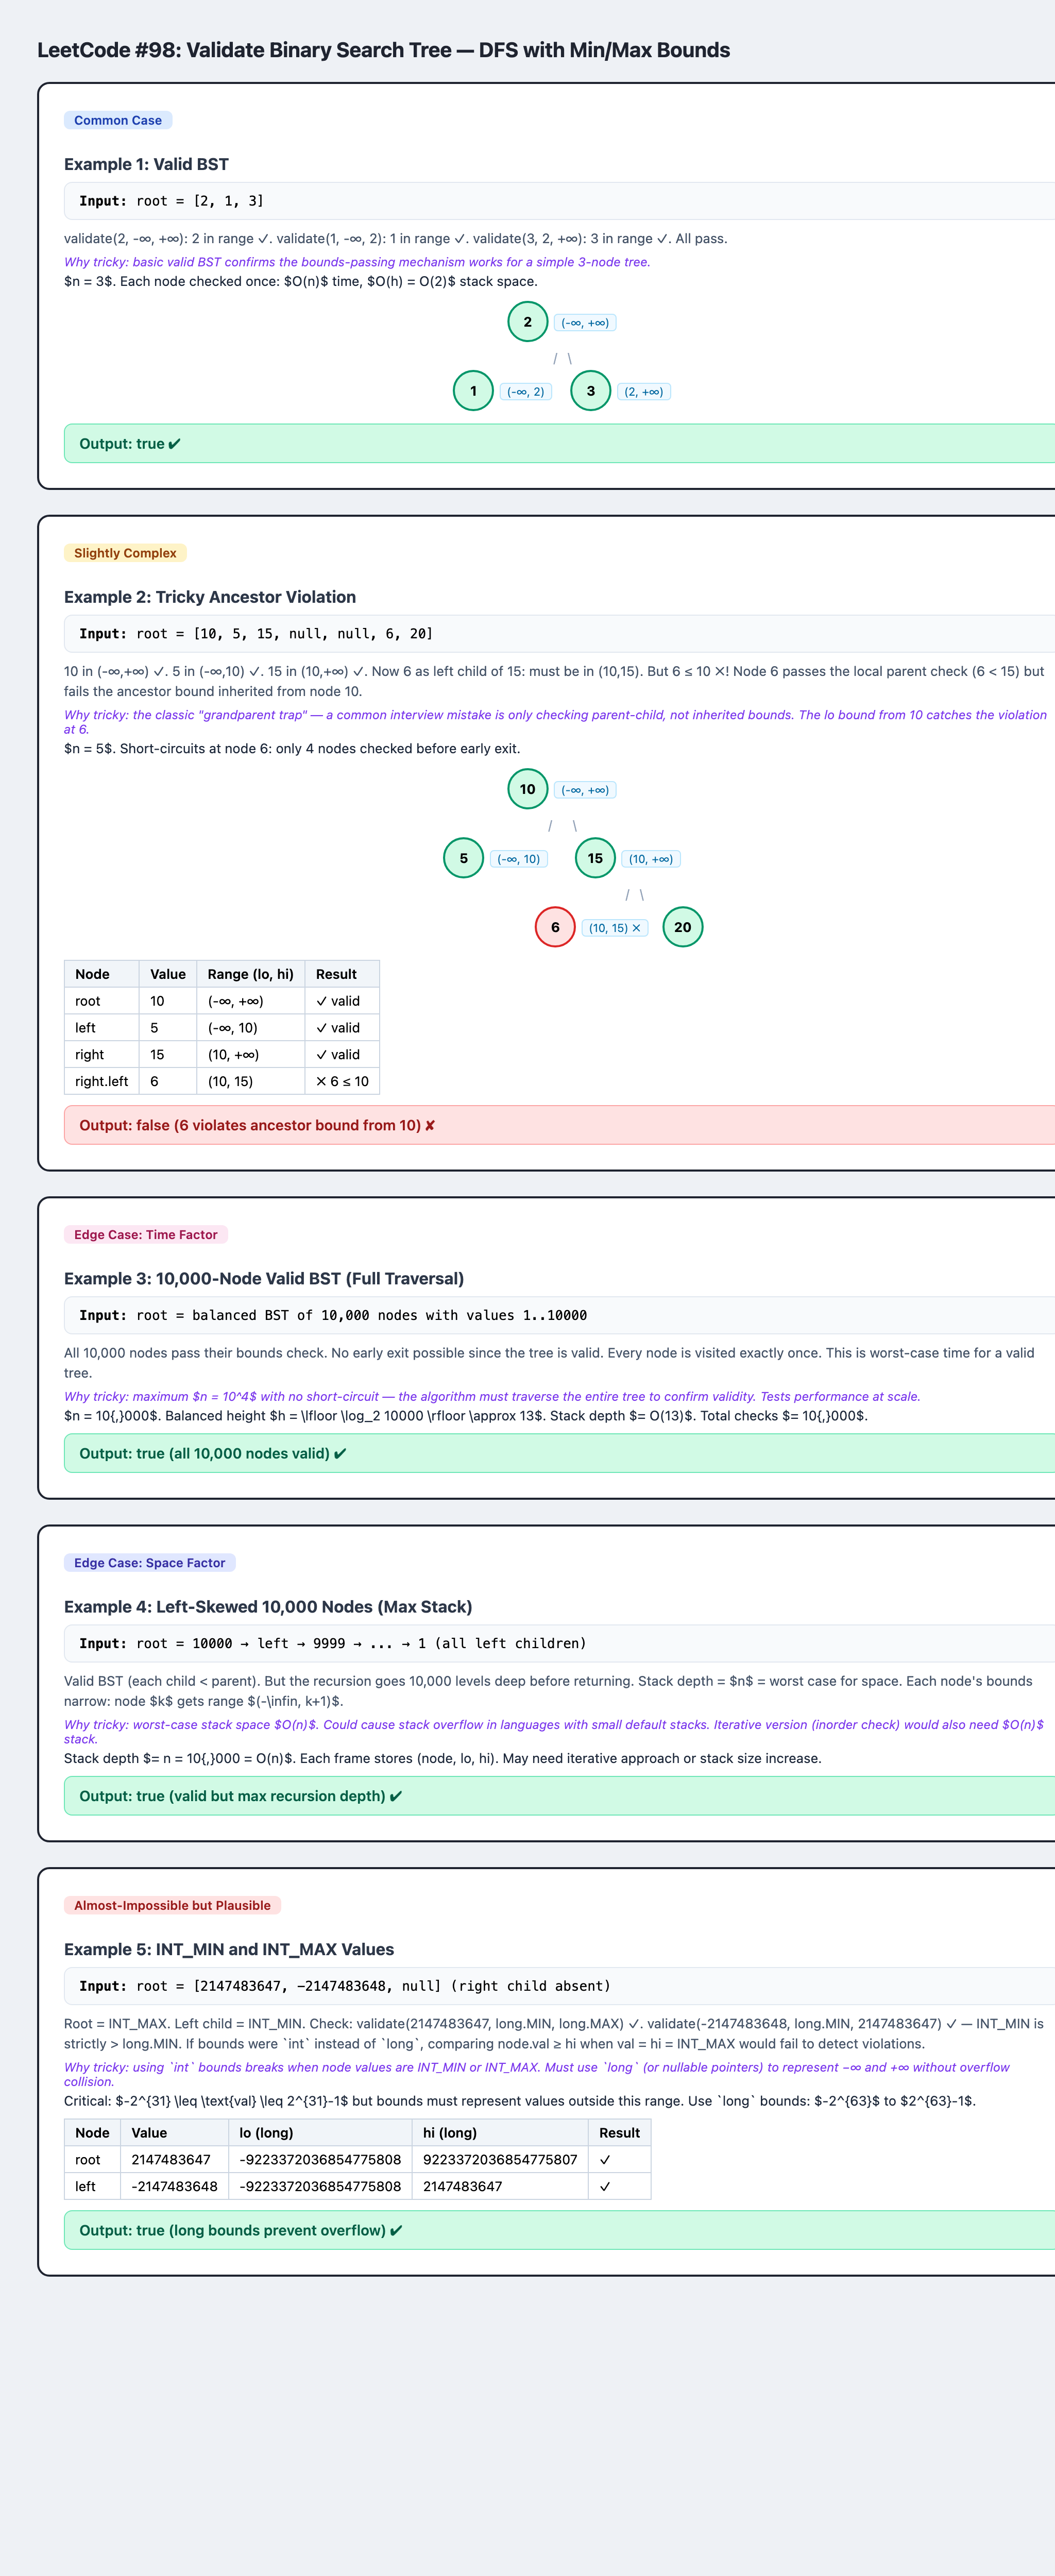